In [1]:
# ═══════════════════════════════════════════════════════
# DREAM NARRATOR — Notebook 02: Train the Neural Encoder
# ═══════════════════════════════════════════════════════
# PURPOSE: Train the autoencoder interactively and
# visualize how it learns to compress brain features
# into dream fingerprints.

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from configs.config_loader import config
from pipeline.data_loader import load_sleep_recording
from pipeline.preprocessor import bandpass_filter, remove_powerline_noise
from pipeline.feature_extractor import extract_features_from_epoch
from pipeline.neural_encoder import DreamEncoder, DreamEncoderTrainer

print("Imports successful!")

Imports successful!


In [2]:
# ── Load and preprocess data ──
data_dir       = config['data']['raw_dir']
psg_path       = os.path.join(data_dir, config['data']['psg_file'])
hypnogram_path = os.path.join(data_dir, config['data']['hypnogram_file'])

raw, annotations = load_sleep_recording(psg_path, hypnogram_path)
raw = remove_powerline_noise(raw)
raw = bandpass_filter(raw)

sfreq = raw.info['sfreq']
data  = raw.get_data()

print(f"Data loaded: {data.shape}")
print(f"Sampling rate: {sfreq} Hz")

Loading EEG recording from: C:\Users\USER/mne_data/physionet-sleep-data\SC4001E0-PSG.edf
Extracting EDF parameters from C:\Users\USER/mne_data/physionet-sleep-data\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


Loading sleep stage annotations from: C:\Users\USER/mne_data/physionet-sleep-data\SC4001EC-Hypnogram.edf
Removing powerline noise at 50.0 Hz


C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:36: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 47.50 Hz)
- Filter length: 661 samples (6.610 s)

Applying bandpass filter: 0.5 - 45.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff f

In [3]:
# ── Extract features from epochs ──
epoch_duration = int(sfreq * 30)
n_epochs       = min(20, data.shape[1] // epoch_duration)

features_list = []
for i in range(n_epochs):
    start      = i * epoch_duration
    end        = start + epoch_duration
    epoch_data = data[:, start:end]
    features, names = extract_features_from_epoch(epoch_data, sfreq)
    features_list.append(features)

# Normalize
features_array = np.array(features_list)
mean           = features_array.mean(axis=0)
std            = features_array.std(axis=0) + 1e-10
features_norm  = [(f - mean) / std for f in features_list]

print(f"Epochs: {n_epochs}")
print(f"Feature size: {len(features_list[0])}")
print(f"Mean after norm: {np.array(features_norm).mean():.4f}")
print(f"Std after norm:  {np.array(features_norm).std():.4f}")

Epochs: 20
Feature size: 63
Mean after norm: -0.0000
Std after norm:  0.7804


In [4]:
# ── Train encoder and track loss ──
# This time we track loss at every epoch so we can
# visualize the learning curve

input_dim     = len(features_norm[0])
embedding_dim = config['encoder']['embedding_dim']
model         = DreamEncoder(input_dim=input_dim, embedding_dim=embedding_dim)
trainer       = DreamEncoderTrainer(model, learning_rate=0.001)

n_training_epochs = 50  # more epochs than before for better training
loss_history      = []

print(f"Model input dim  : {input_dim}")
print(f"Embedding dim    : {embedding_dim}")
print(f"Training epochs  : {n_training_epochs}")
print(f"Training device  : {trainer.device}")
print("\nTraining...")

for epoch in range(n_training_epochs):
    avg_loss = trainer.train_epoch(features_norm)
    loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_training_epochs} | Loss: {avg_loss:.6f}")

print("\nTraining complete!")
print(f"Initial loss : {loss_history[0]:.6f}")
print(f"Final loss   : {loss_history[-1]:.6f}")
print(f"Improvement  : {(1 - loss_history[-1]/loss_history[0])*100:.1f}%")

Training on: cpu
Model input dim  : 63
Embedding dim    : 16
Training epochs  : 50
Training device  : cpu

Training...
Epoch  10/50 | Loss: 0.287277
Epoch  20/50 | Loss: 0.154911
Epoch  30/50 | Loss: 0.104176
Epoch  40/50 | Loss: 0.089752
Epoch  50/50 | Loss: 0.082827

Training complete!
Initial loss : 0.877264
Final loss   : 0.082827
Improvement  : 90.6%


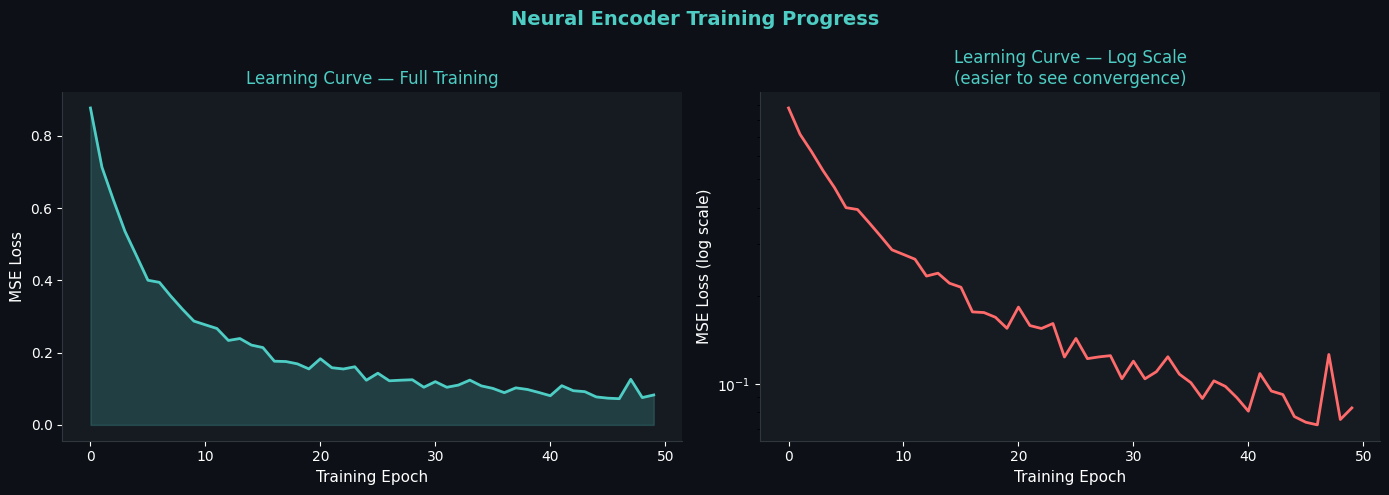

Flat curve at the end = model has converged
Still dropping = train longer
Spikes = learning rate too high


In [5]:
# ── Plot learning curve ──
# The learning curve shows how the model improves over time.
# A good learning curve:
# - Drops steeply at first (fast learning)
# - Flattens out (convergence)
# - No sudden spikes (stable training)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D1117')

# Left: full learning curve
ax1 = axes[0]
ax1.set_facecolor('#161B22')
ax1.plot(loss_history, color='#4ECDC4', linewidth=2)
ax1.fill_between(range(len(loss_history)),
                loss_history, alpha=0.2, color='#4ECDC4')
ax1.set_xlabel('Training Epoch', color='white', fontsize=11)
ax1.set_ylabel('MSE Loss', color='white', fontsize=11)
ax1.set_title('Learning Curve — Full Training',
             color='#4ECDC4', fontsize=12)
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: log scale to see fine details
ax2 = axes[1]
ax2.set_facecolor('#161B22')
ax2.plot(loss_history, color='#FF6B6B', linewidth=2)
ax2.set_yscale('log')
ax2.set_xlabel('Training Epoch', color='white', fontsize=11)
ax2.set_ylabel('MSE Loss (log scale)', color='white', fontsize=11)
ax2.set_title('Learning Curve — Log Scale\n(easier to see convergence)',
             color='#4ECDC4', fontsize=12)
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Neural Encoder Training Progress',
            color='#4ECDC4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Flat curve at the end = model has converged")
print("Still dropping = train longer")
print("Spikes = learning rate too high")

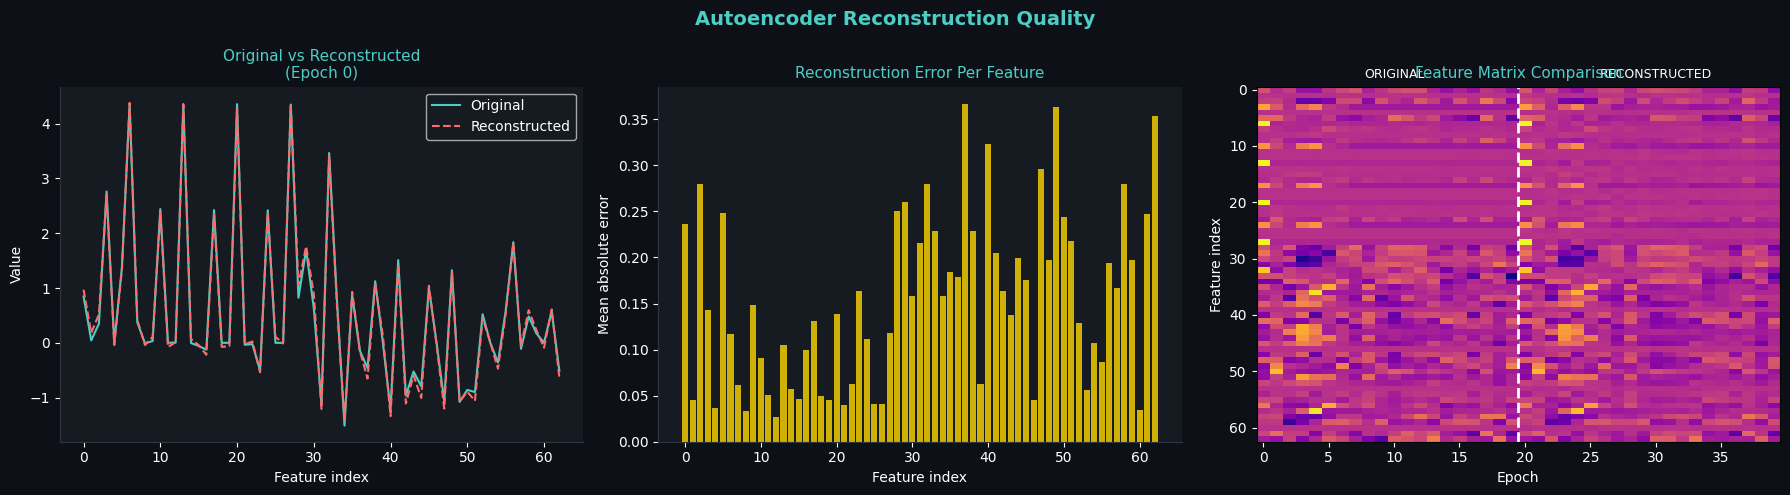

Mean reconstruction error: 0.1549
Quality score: 84.5%


In [6]:
# ── Test reconstruction quality ──
# The autoencoder compresses features → embedding → reconstructs features
# Good reconstruction = embedding preserved the information
# Bad reconstruction = embedding lost important information

model.eval()
reconstructions = []
originals       = []

with torch.no_grad():
    for features in features_norm:
        x                   = torch.FloatTensor(features).unsqueeze(0)
        embedding, recon    = model(x)
        originals.append(features)
        reconstructions.append(recon.numpy().flatten())

originals       = np.array(originals)
reconstructions = np.array(reconstructions)

# Compute per-feature reconstruction error
recon_error = np.abs(originals - reconstructions).mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0D1117')

# Left: original vs reconstructed for epoch 0
ax1 = axes[0]
ax1.set_facecolor('#161B22')
ax1.plot(originals[0], color='#4ECDC4',
        label='Original', linewidth=1.5)
ax1.plot(reconstructions[0], color='#FF6B6B',
        label='Reconstructed', linewidth=1.5, linestyle='--')
ax1.set_title('Original vs Reconstructed\n(Epoch 0)',
             color='#4ECDC4', fontsize=11)
ax1.set_xlabel('Feature index', color='white')
ax1.set_ylabel('Value', color='white')
ax1.legend(facecolor='#161B22', labelcolor='white')
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Middle: reconstruction error per feature
ax2 = axes[1]
ax2.set_facecolor('#161B22')
ax2.bar(range(len(recon_error)), recon_error,
       color='#FFD700', alpha=0.8)
ax2.set_title('Reconstruction Error Per Feature',
             color='#4ECDC4', fontsize=11)
ax2.set_xlabel('Feature index', color='white')
ax2.set_ylabel('Mean absolute error', color='white')
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Right: original vs reconstructed heatmap
ax3 = axes[2]
ax3.set_facecolor('#161B22')
comparison = np.vstack([originals, reconstructions])
ax3.imshow(comparison.T, aspect='auto',
          cmap='plasma', interpolation='nearest')
ax3.axvline(x=n_epochs-0.5, color='white',
           linewidth=2, linestyle='--')
ax3.text(n_epochs/2, -2, 'ORIGINAL',
        color='white', ha='center', fontsize=9)
ax3.text(n_epochs*1.5, -2, 'RECONSTRUCTED',
        color='white', ha='center', fontsize=9)
ax3.set_title('Feature Matrix Comparison',
             color='#4ECDC4', fontsize=11)
ax3.set_xlabel('Epoch', color='white')
ax3.set_ylabel('Feature index', color='white')
ax3.tick_params(colors='white')

plt.suptitle('Autoencoder Reconstruction Quality',
            color='#4ECDC4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

total_error = recon_error.mean()
print(f"Mean reconstruction error: {total_error:.4f}")
print(f"Quality score: {(1-total_error)*100:.1f}%")

In [7]:
# ── Save the newly trained model ──
# This model was trained for 50 epochs vs 20 before
# It should produce better dream fingerprints

model_path = os.path.join('..', config['encoder']['model_path'])
trainer.save_model(model_path)

print(f"Model saved to: {model_path}")
print(f"Trained for: {n_training_epochs} epochs")
print(f"Final loss: {loss_history[-1]:.6f}")
print("\nThis model will be used by the full pipeline")
print("Run main.py to generate a dream narrative with this improved model!")

Model saved to: ..\models/dream_encoder.pt
Model saved to: ..\models/dream_encoder.pt
Trained for: 50 epochs
Final loss: 0.082827

This model will be used by the full pipeline
Run main.py to generate a dream narrative with this improved model!
